¡Éxito total! Se han cargado y limpiado 7937 filas directamente desde el GitHub de nicollegaviria7.


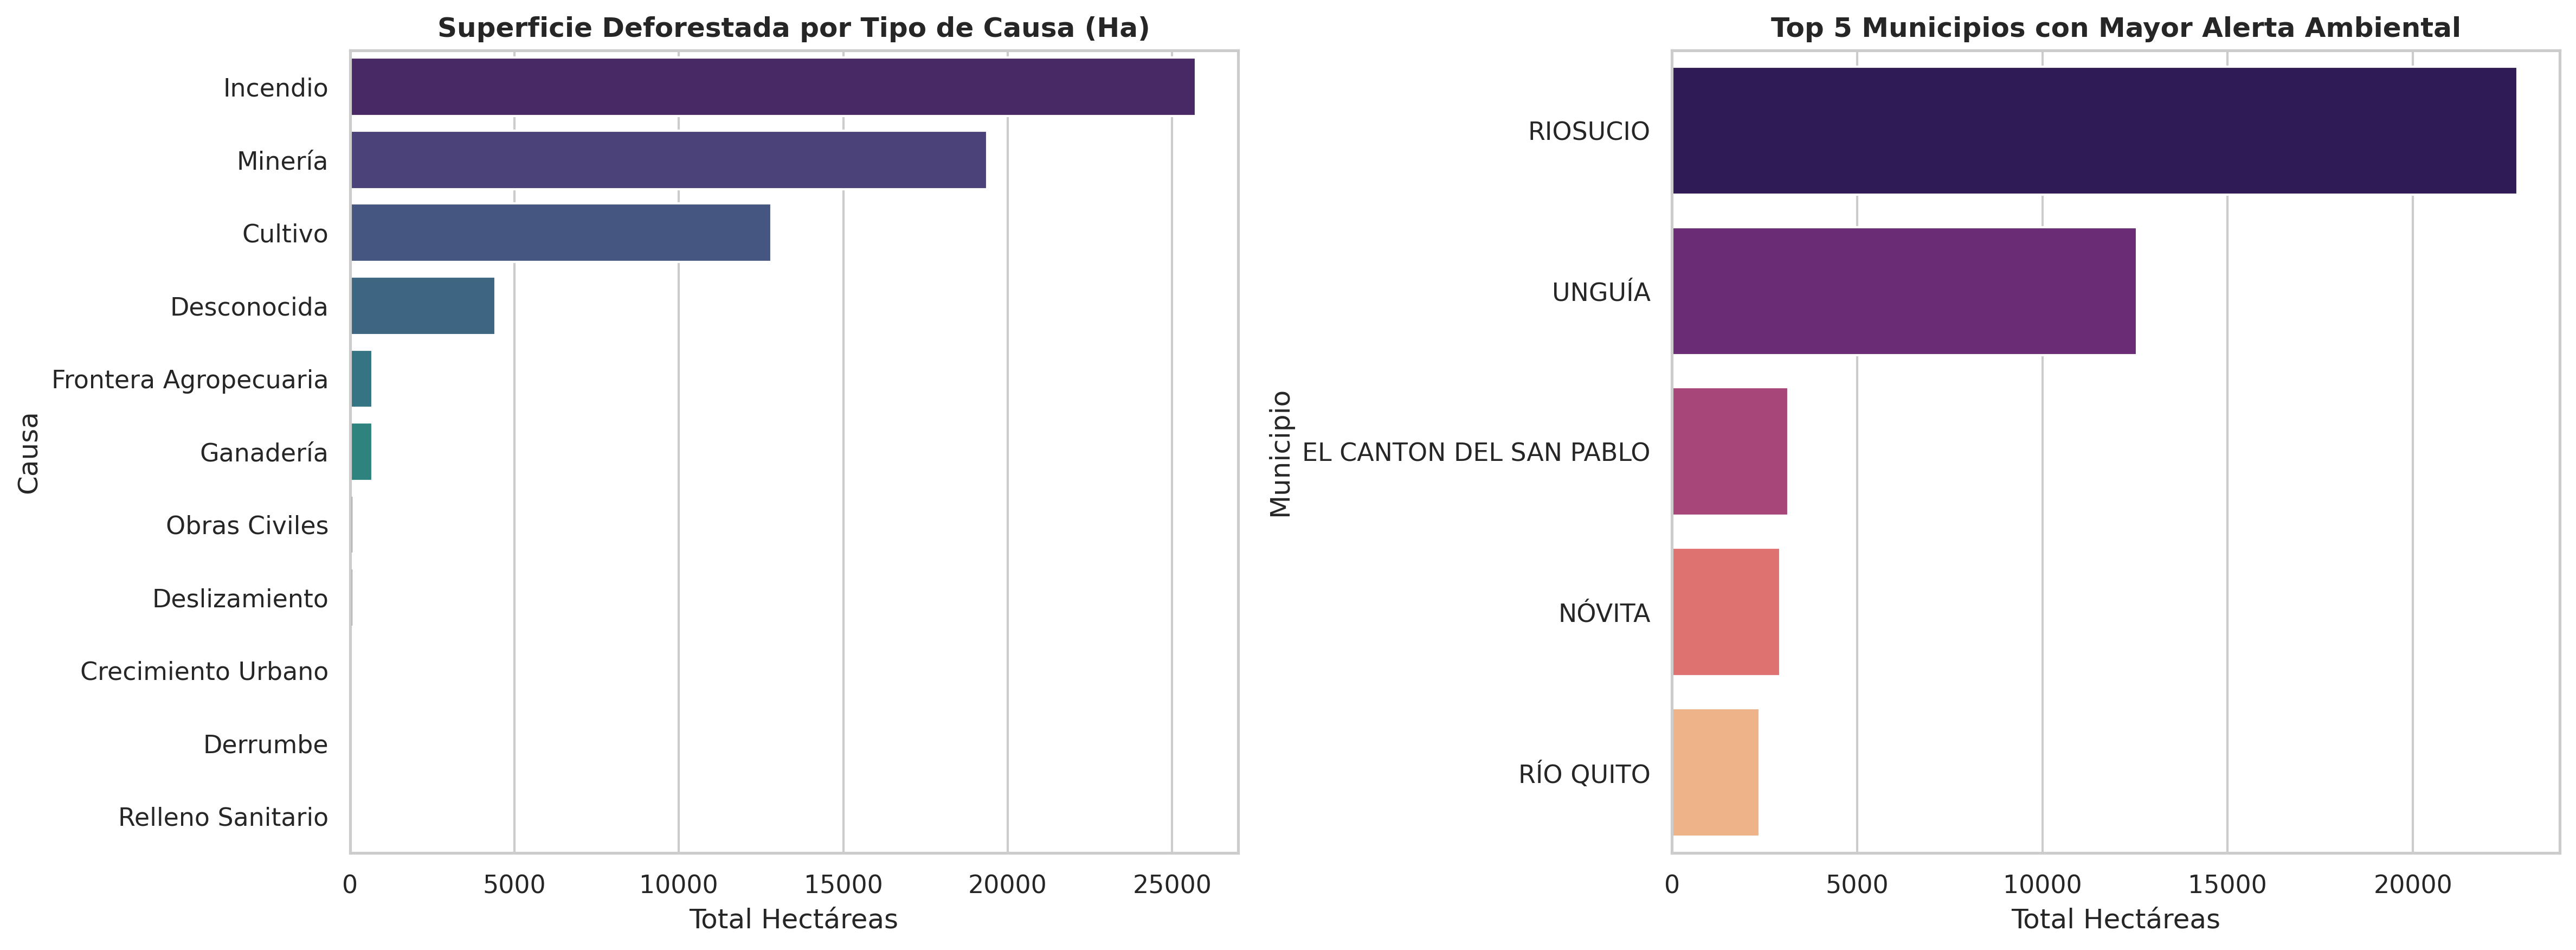

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar los datos directamente desde tu repositorio de GitHub (Validando Mayúsculas)
url_github = "https://raw.githubusercontent.com/nicollegaviria7/Proyecto-BigData-Deforestacion-Choco/main/AREAS_DEFORESTADAS_CHOCO_20260619.csv"

# Leer el archivo de forma remota
df = pd.read_csv(url_github)

# 2. Limpieza de datos (Simulación de Capa Silver)
df['AREA_Ha_clean'] = df['AREA_Ha'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

mapping_anios = {"2.02": 2020, "2.019": 2019, "2.021": 2021, "2.014": 2014, "2.018": 2018, "2.015": 2015, "2.017": 2017, "2.016": 2016}
df['ANIO_clean'] = df['AÑO'].astype(str).str.strip().apply(lambda x: mapping_anios.get(x, int(float(x)) if x != 'nan' and x != '2.0' else 2014))
df['CAUSA'] = df['CAUSA'].fillna('Desconocida')

print(f"¡Éxito total! Se han cargado y limpiado {len(df)} filas directamente desde el GitHub de nicollegaviria7.")

# 3. Creación de Gráficos de Alta Resolución para el Reporte
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
sns.set_theme(style="whitegrid")

# Gráfico A: Hectáreas afectadas por Causa Principal
causas_df = df.groupby('CAUSA')['AREA_Ha_clean'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=causas_df, x='AREA_Ha_clean', y='CAUSA', ax=axes[0], palette='viridis', hue='CAUSA', legend=False)
axes[0].set_title('Superficie Deforestada por Tipo de Causa (Ha)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Hectáreas')
axes[0].set_ylabel('Causa')

# Gráfico B: Top 5 Municipios con Mayor Impacto Territorial
municipios_df = df.groupby('MUNICIPIO')['AREA_Ha_clean'].sum().sort_values(ascending=False).head(5).reset_index()
sns.barplot(data=municipios_df, x='AREA_Ha_clean', y='MUNICIPIO', ax=axes[1], palette='magma', hue='MUNICIPIO', legend=False)
axes[1].set_title('Top 5 Municipios con Mayor Alerta Ambiental', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Hectáreas')
axes[1].set_ylabel('Municipio')

plt.tight_layout()
plt.savefig('analisis_deforestacion_choco.png', bbox_inches='tight')
plt.show()